# Análisis Exploratorio de Datos (EDA)

Este notebook documenta la fase de exploración y entendimiento de la base `Base_de_datos.csv`. El objetivo es identificar patrones, validar supuestos de calidad y preparar información relevante para los pasos de ingeniería de características y modelado supervisado.

## Agenda del notebook
1. Configuración y carga de datos
2. Evaluación de calidad y tipificación
3. Análisis univariable (numérico y categórico)
4. Análisis bivariante respecto al objetivo
5. Exploración multivariable y correlaciones
6. Hallazgos clave y lineamientos para ingeniería de características
7. Espacio para comentarios del analista


### 1.0 Contexto del dataset
El conjunto de datos proviene del repositorio "Predict Students' Dropout and Academic Success" (Kaggle). Contiene 4.424 registros y 35 atributos que combinan información demográfica, socioeconómica y académica de estudiantes universitarios. El objetivo (`Target`) clasifica el estado del estudiante en tres categorías: `Dropout`, `Enrolled` y `Graduate`. Esta sección documenta la comprensión inicial requerida por la guía del proyecto.


In [76]:
# 1. Configuración y carga de datos
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from pandas.api.types import is_numeric_dtype, is_bool_dtype
from scipy import stats

sns.set_theme(style="whitegrid")
plt.style.use("seaborn-v0_8")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


### 1.1 Parámetros globales
Se fijan estilos gráficos y formatos de impresión para garantizar consistencia entre ejecuciones y facilitar la lectura de reportes exportados.


In [77]:
# Cargar configuración y dataset base
config_path = Path("../../config.json")
with open(config_path, "r", encoding="utf-8") as fp:
    config = json.load(fp)

project_identifier = config.get("project_code", "desconocido")
pipeline_config = config.get("pipeline_config", {})

if "data_path" not in pipeline_config:
    raise KeyError(
        "El archivo config.json no contiene la clave 'pipeline_config[\"data_path\"]'. "
        "Verifica la configuración antes de continuar con el EDA."
    )

data_path = Path("../../") / pipeline_config["data_path"]
print(f"Proyecto: {project_identifier}")
print(f"Ruta de origen de datos: {data_path}")

raw_df = pd.read_csv(data_path, sep=";", encoding="utf-8")
print(f"Dimensión original: {raw_df.shape}")


Proyecto: proyecto_ml
Ruta de origen de datos: ..\..\Base_de_datos.csv
Dimensión original: (4424, 37)


In [78]:
# Normalizar nombres de columnas para evitar espacios o tabulaciones residuales
raw_df.columns = (
    raw_df.columns
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)



### 1.2 Copia de trabajo
Se crea una copia para mantener la data original sin modificaciones, permitiendo trazabilidad entre extracción y transformaciones.


In [79]:
df = raw_df.copy()
print("Copia de trabajo creada correctamente")


Copia de trabajo creada correctamente


## 2. Evaluación de calidad y tipificación


In [80]:
display(df.head(3))
display(df.tail(3))
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.00,1,19,12,5,9,127.30,1,0,0,1,1,0,20,0,0,0,0,0,0.00,0,0,0,0,0,0.00,0,10.80,1.40,1.74,Dropout
1,1,15,1,9254,1,1,160.00,1,1,3,3,3,142.50,1,0,0,0,1,0,19,0,0,6,6,6,14.00,0,0,6,6,6,13.67,0,13.90,-0.30,0.79,Graduate
2,1,1,5,9070,1,1,122.00,1,37,37,9,9,124.80,1,0,0,0,1,0,19,0,0,6,0,0,0.00,0,0,6,0,0,0.00,0,10.80,1.40,1.74,Dropout


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4421,1,1,1,9500,1,1,154.00,1,37,37,9,9,149.50,1,0,0,1,0,1,30,0,0,7,8,7,14.91,0,0,8,9,1,13.50,0,13.90,-0.30,0.79,Dropout
4422,1,1,1,9147,1,1,180.00,1,37,37,7,4,153.80,1,0,0,1,0,1,20,0,0,5,5,5,13.80,0,0,5,6,5,12.00,0,9.40,-0.80,-3.12,Graduate
4423,1,10,1,9773,1,1,152.00,22,38,37,5,9,152.00,1,0,0,1,0,0,22,1,0,6,8,6,11.67,0,0,6,6,6,13.00,0,12.70,3.70,-1.70,Graduate


Filas: 4424 | Columnas: 37


### 2.1 Auditoría de valores faltantes
Se inspeccionan representaciones explícitas (NaN) y se homologan valores atípicos ('na', '?', strings vacíos) para mantener consistencia en el pipeline.


> **Nulos:** tras homologar representaciones equivalentes (`"na"`, `"-"`, etc.) no se detectaron valores faltantes en ninguna columna. Esto simplifica la etapa de imputación posterior (solo se aplicará por consistencia en el pipeline).


In [81]:
custom_na_values = ["na", "n/a", "NA", "", "?", "None", "null", "-", "--"]

df.replace(custom_na_values, np.nan, inplace=True)
missing_overview = pd.DataFrame({
    "valores_faltantes": df.isna().sum(),
    "porcentaje": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("porcentaje", ascending=False)

missing_overview


,valores_faltantes,porcentaje
Marital status,0,0.00
Application mode,0,0.00
Application order,0,0.00
Course,0,0.00
Daytime/evening attendance,0,0.00
Previous qualification,0,0.00
Previous qualification (grade),0,0.00
Nacionality,0,0.00
Mother's qualification,0,0.00
Father's qualification,0,0.00


### 2.2 Duplicados y consistencia básica


In [82]:
duplicate_count = df.duplicated().sum()
print(f"Registros duplicados detectados: {duplicate_count}")

negative_counts = (df.select_dtypes(include=[np.number]) < 0).sum().sort_values(ascending=False)
negative_counts.head()


Registros duplicados detectados: 0


GDP                 1711
Inflation rate       923
Marital status         0
Application mode       0
Course                 0
dtype: int64

### 2.3 Tipificación de columnas
Identificamos variables categóricas, ordinales y binarias que llegan codificadas como enteros. Estas conversiones facilitan interpretaciones y gráficos posteriores.


In [83]:
binary_like_cols = [
    "Gender",
    "Scholarship holder",
    "Debtor",
    "Tuition fees up to date",
    "Displaced",
    "Educational special needs",
    "International"
]

categorical_int_cols = [
    "Marital status",
    "Application mode",
    "Application order",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nacionality" if "Nacionality" in df.columns else "Nationality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

for col in binary_like_cols:
    if col in df.columns:
        df[col] = df[col].astype("Int64").astype("category")

for col in categorical_int_cols:
    if col in df.columns:
        df[col] = df[col].astype("Int64").astype("category")

# Target y codificaciÃ³n auxiliar
if df["Target"].dtype != "category":
    df["Target"] = df["Target"].astype("category")

target_mapping = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
df["Target_id"] = df["Target"].map(target_mapping)

schema_types = pd.DataFrame({
    "columna": df.columns,
    "tipo_pandas": df.dtypes.astype(str)
}).sort_values("columna")

schema_types


,columna,tipo_pandas
Admission grade,Admission grade,float64
Age at enrollment,Age at enrollment,int64
Application mode,Application mode,category
Application order,Application order,category
Course,Course,category
Curricular units 1st sem (approved),Curricular units 1st sem (approved),int64
Curricular units 1st sem (credited),Curricular units 1st sem (credited),int64
Curricular units 1st sem (enrolled),Curricular units 1st sem (enrolled),int64
Curricular units 1st sem (evaluations),Curricular units 1st sem (evaluations),int64
Curricular units 1st sem (grade),Curricular units 1st sem (grade),float64


In [84]:
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
if "Target_id" not in numeric_columns:
    numeric_columns.append("Target_id")

categorical_columns = [col for col in df.columns if df[col].dtype.name == "category" and col != "Target"]

print(f"Variables numéricas: {len(numeric_columns)}")
print(f"Variables categóricas: {len(categorical_columns)}")


Variables numéricas: 19
Variables categóricas: 19


**Caracterización de variables:**
- **Numéricas continuas** (19 columnas): métricas académicas (creditaje, aprobaciones, notas, indicadores macroeconómicos) junto con `Age at enrollment`. Se mantienen en `numeric_columns` para análisis estadísticos.
- **Categóricas dicotómicas** (7 columnas): `Gender`, `Scholarship holder`, `Debtor`, `Tuition fees up to date`, `Displaced`, `Educational special needs`, `International`. Se tratan como tipo `category` para facilitar conteos y cálculo de V de Cramér.
- **Categóricas politómicas / ordinales** (12 columnas): variables administrativas (`Marital status`, `Application mode`, `Course`, `Daytime/evening attendance`, etc.) codificadas como enteros. Algunas poseen orden natural (p. ej. `Application order`), otras son nominales pero con múltiples niveles.
- **Variable objetivo**: `Target` con tres estados (`Dropout`, `Enrolled`, `Graduate`) y su representación numérica `Target_id` (0/1/2) utilizada para correlaciones.

Esta clasificación permite diferenciar estrategias de limpieza, imputación y codificación en la fase de feature engineering.


## 3. Análisis univariable


In [85]:
numeric_summary = df[numeric_columns].describe().T
numeric_summary[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)


,count,mean,std,min,25%,50%,75%,max
Previous qualification (grade),"4,424.00",132.61,13.19,95.00,125.00,133.10,140.00,190.00
Admission grade,"4,424.00",126.98,14.48,95.00,117.90,126.10,134.80,190.00
Age at enrollment,"4,424.00",23.27,7.59,17.00,19.00,20.00,25.00,70.00
Curricular units 1st sem (credited),"4,424.00",0.71,2.36,0.00,0.00,0.00,0.00,20.00
Curricular units 1st sem (enrolled),"4,424.00",6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular units 1st sem (evaluations),"4,424.00",8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular units 1st sem (approved),"4,424.00",4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular units 1st sem (grade),"4,424.00",10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular units 1st sem (without evaluations),"4,424.00",0.14,0.69,0.00,0.00,0.00,0.00,12.00
Curricular units 2nd sem (credited),"4,424.00",0.54,1.92,0.00,0.00,0.00,0.00,19.00


In [86]:
numeric_df = df.select_dtypes(include=[np.number])

moments = pd.DataFrame({
    "media": numeric_df.mean(),
    "mediana": numeric_df.median(),
    "moda": numeric_df.mode().iloc[0],
    "desviación_std": numeric_df.std(),
    "sesgo": numeric_df.skew(),
    "curtosis": numeric_df.kurtosis()
}).round(3)

moments


,media,mediana,moda,desviación_std,sesgo,curtosis
Previous qualification (grade),132.61,133.10,133.10,13.19,0.31,0.97
Admission grade,126.98,126.10,130.00,14.48,0.53,0.66
Age at enrollment,23.27,20.00,18.00,7.59,2.06,4.13
Curricular units 1st sem (credited),0.71,0.00,0.00,2.36,4.17,19.21
Curricular units 1st sem (enrolled),6.27,6.00,6.00,2.48,1.62,8.94
Curricular units 1st sem (evaluations),8.30,8.00,8.00,4.18,0.98,5.46
Curricular units 1st sem (approved),4.71,5.00,6.00,3.09,0.77,3.10
Curricular units 1st sem (grade),10.64,12.29,0.00,4.84,-1.57,0.91
Curricular units 1st sem (without evaluations),0.14,0.00,0.00,0.69,8.21,89.86
Curricular units 2nd sem (credited),0.54,0.00,0.00,1.92,4.63,24.43


**Resumen univariable:** Las columnas de rendimiento (`Curricular units ...` y `grade`) muestran distribuciones ligeramente asimétricas a la izquierda (sesgo negativo), lo cual es consistente con la concentración de estudiantes aprobando la mayoría de materias. La edad presenta ligera asimetría positiva, indicando un pequeño grupo de estudiantes mayores. Estos hallazgos orientan el uso de transformaciones (p.ej. escalado robusto) en la fase de modelado.


### 3.1 Distribuciones numéricas
Se analizan las variables con mayor relación aparente con el desempeño académico para detectar asimetrías, valores extremos y posibles transformaciones.


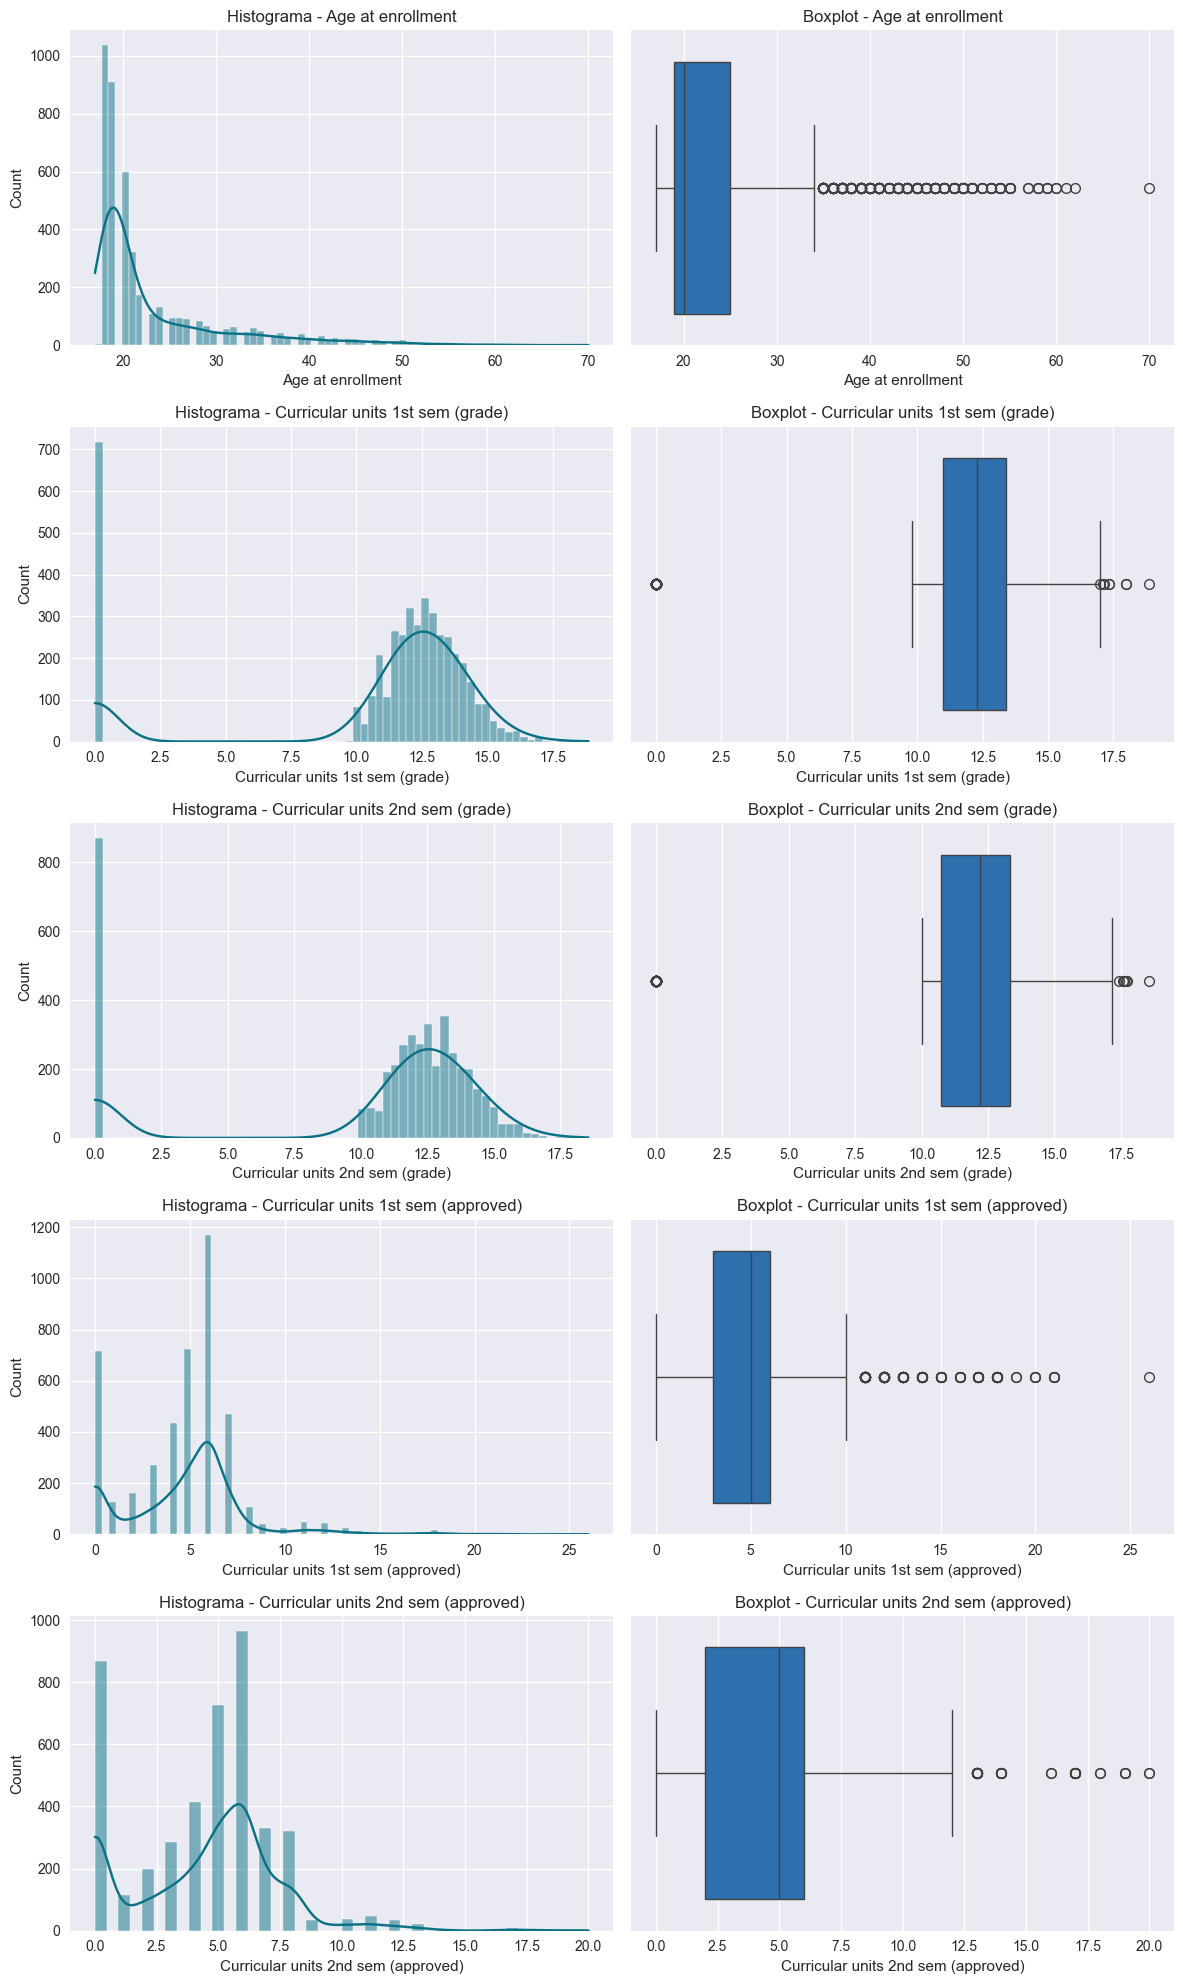

In [87]:
important_numeric = [
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)"
]

fig, axes = plt.subplots(nrows=len(important_numeric), ncols=2, figsize=(12, 4 * len(important_numeric)))

for idx, col in enumerate(important_numeric):
    sns.histplot(df[col], kde=True, ax=axes[idx, 0], color="#0B7285")
    axes[idx, 0].set_title(f"Histograma - {col}")
    sns.boxplot(x=df[col], ax=axes[idx, 1], color="#1971C2")
    axes[idx, 1].set_title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()


### 3.2 Variables categóricas
Revisamos la distribución de variables administrativas y socioeconómicas para identificar segmentos relevantes y clases poco representadas.


C:\Users\jesus\AppData\Local\Temp\ipykernel_235376\668226852.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\jesus\AppData\Local\Temp\ipykernel_235376\668226852.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\jesus\AppData\Local\Temp\ipykernel_235376\668226852.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\jesus\AppData\Local\Temp\ipykernel_235376\668226852.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

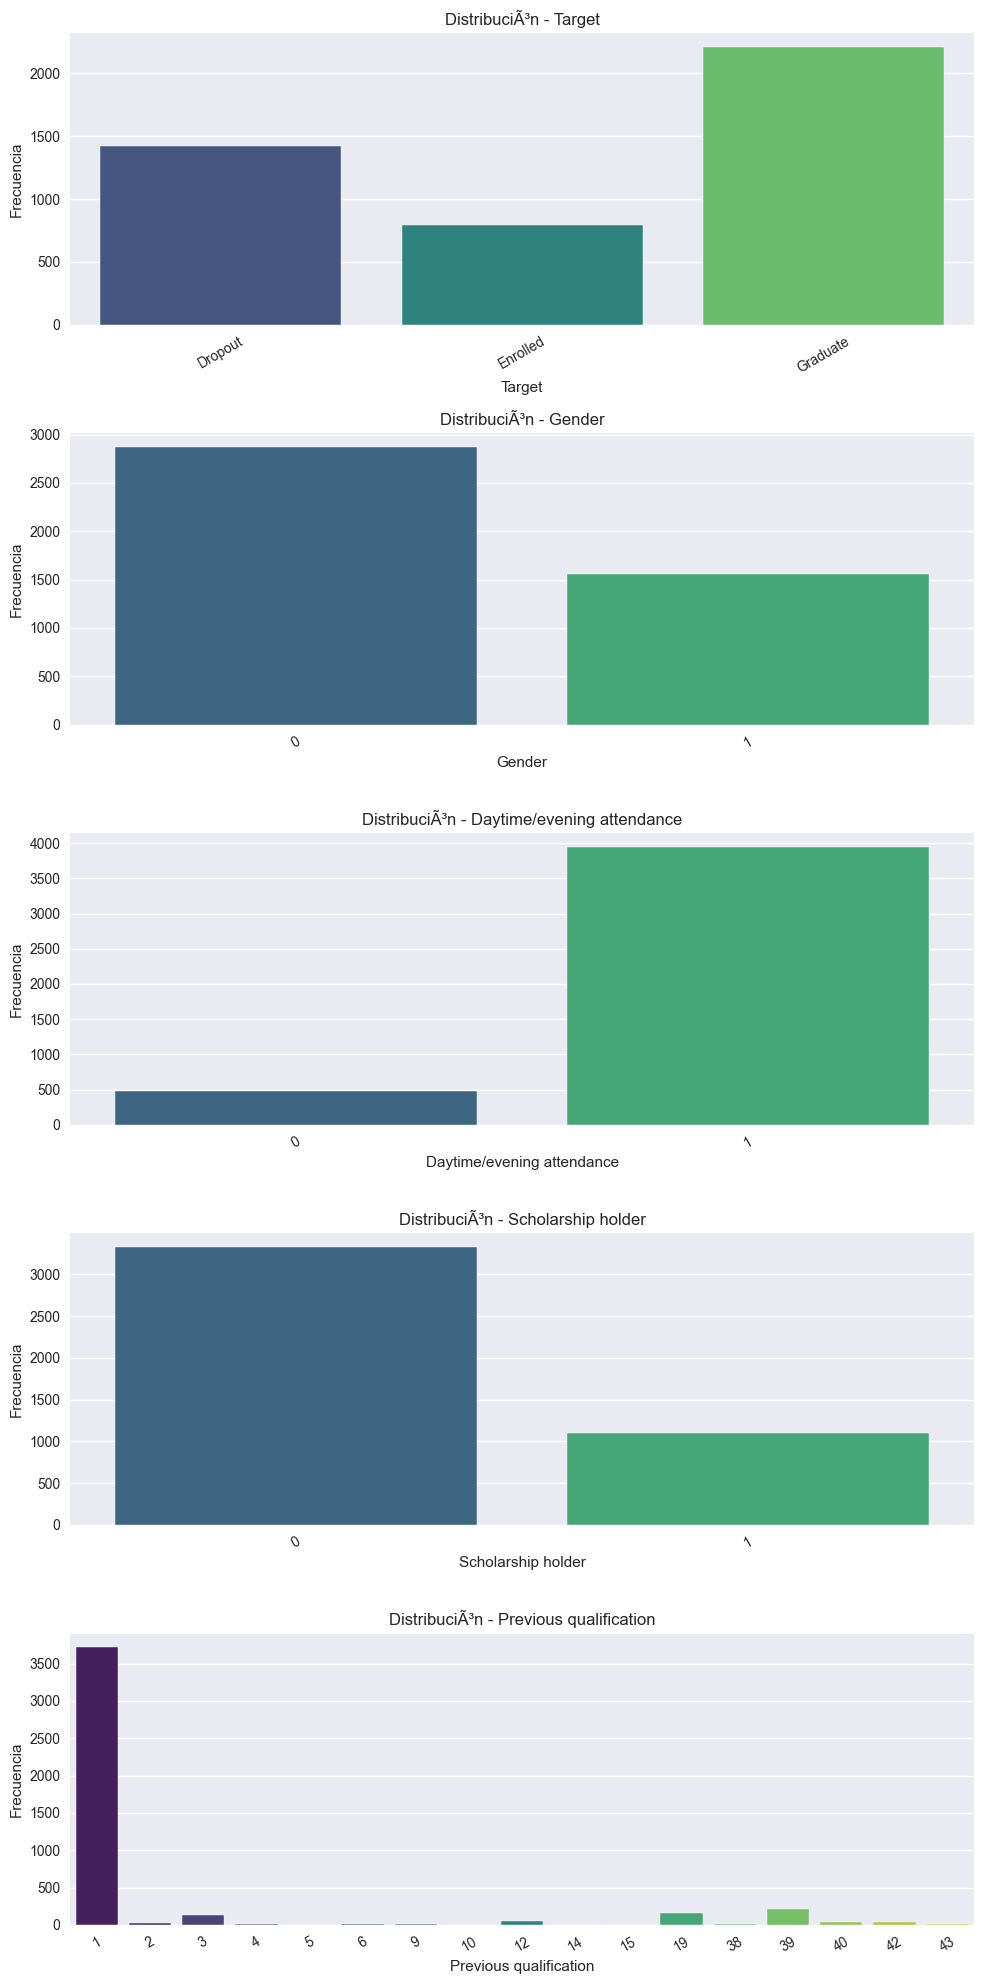

,Target,Gender,Daytime/evening attendance,Scholarship holder,Previous qualification
count,4424,4424,4424,4424,4424
unique,3,2,2,2,17
top,Graduate,0,1,0,1
freq,2209,2868,3941,3325,3717


In [88]:
categorical_focus = [
    "Target",
    "Gender",
    "Daytime/evening attendance",
    "Scholarship holder",
    "Previous qualification"
]

fig, axes = plt.subplots(nrows=len(categorical_focus), ncols=1, figsize=(10, 4 * len(categorical_focus)))

for idx, col in enumerate(categorical_focus):
    sns.countplot(data=df, x=col, ax=axes[idx], palette="viridis")
    axes[idx].set_title(f"DistribuciÃ³n - {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Frecuencia")
    axes[idx].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

df[categorical_focus].describe(include="all")


## 4. Análisis bivariante respecto al objetivo


In [89]:
target_balance = df["Target"].value_counts(normalize=True).rename("participaciÃ³n").mul(100).round(2)
display(target_balance)

numeric_vs_target = df.groupby("Target")[important_numeric].agg(["mean", "median"]).round(2)
numeric_vs_target


Target
Graduate   49.93
Dropout    32.12
Enrolled   17.95
Name: participaciÃ³n, dtype: float64

C:\Users\jesus\AppData\Local\Temp\ipykernel_235376\3912447702.py:4: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Age at enrollment        Curricular units 1st sem (grade)         \
                      mean median                             mean median   
Target                                                                      
Dropout              26.07  23.00                             7.26  10.93   
Enrolled             22.37  20.00                            11.13  12.00   
Graduate             21.78  19.00                            12.64  13.00   

         Curricular units 2nd sem (grade)         \
                                     mean median   
Target                                             
Dropout                              5.90   0.00   
Enrolled                            11.12  12.00   
Graduate                            12.70  13.00   

         Curricular units 1st sem (approved)         \
                                        mean median   
Target                                                
Dropout                                 2.55   2.00   
Enrolled                                4.32   5.00   
Graduate                                6.23   6.00   

         Curricular units 2nd sem (approved)         
                                        mean median  
Target                                               
Dropout                                 1.94   0.00  
Enrolled                                4.06   4.00  
Graduate                                6.18   6.00

In [90]:
px.scatter(
    df,
    x="Curricular units 1st sem (approved)",
    y="Curricular units 2nd sem (approved)",
    color="Target",
    trendline="ols",
    title="RelaciÃ³n entre asignaturas aprobadas y estado del estudiante"
)


Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.70,20.00,41.30
1,12.20,11.80,76.00


Target,Dropout,Enrolled,Graduate
Daytime/evening attendance,,,
0,42.90,15.50,41.60
1,30.80,18.20,51.00


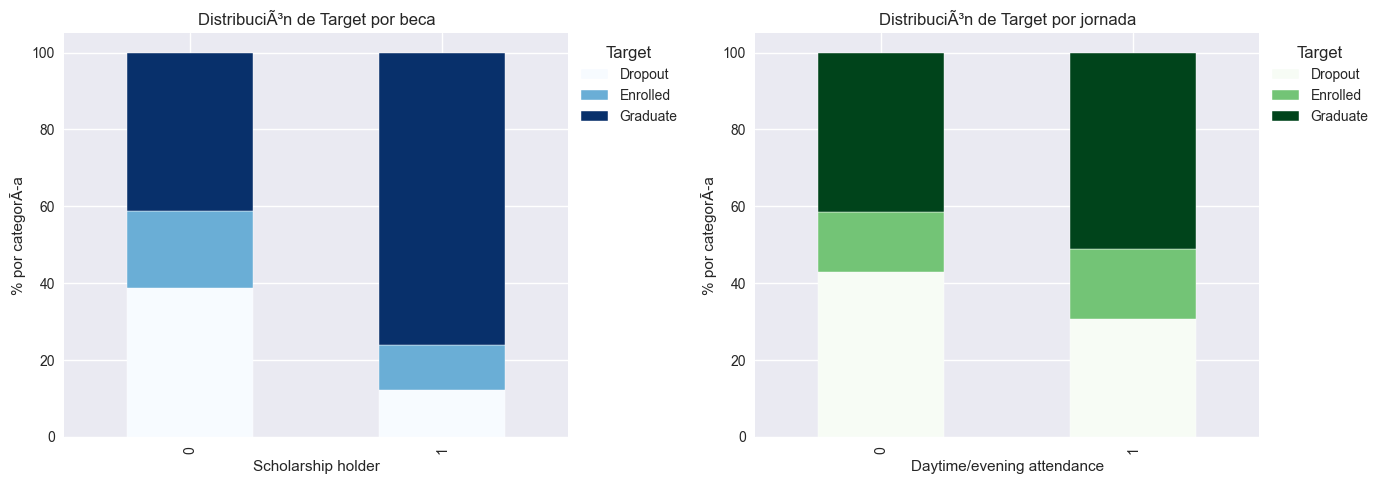

In [91]:
pivot_scholarship = pd.crosstab(df["Scholarship holder"], df["Target"], normalize="index").round(3) * 100
pivot_attendance = pd.crosstab(df["Daytime/evening attendance"], df["Target"], normalize="index").round(3) * 100

display(pivot_scholarship)
display(pivot_attendance)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot_scholarship.plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues")
axes[0].set_title("DistribuciÃ³n de Target por beca")
axes[0].set_ylabel("% por categorÃ­a")
axes[0].legend(title="Target", bbox_to_anchor=(1.0, 1.0))

pivot_attendance.plot(kind="bar", stacked=True, ax=axes[1], colormap="Greens")
axes[1].set_title("DistribuciÃ³n de Target por jornada")
axes[1].set_ylabel("% por categorÃ­a")
axes[1].legend(title="Target", bbox_to_anchor=(1.0, 1.0))

plt.tight_layout()
plt.show()


### 4.2 Interpretación de relaciones bivariantes
- **Becas:** Una proporción mayor de estudiantes con beca permanece matriculada o se gradúa, indicando que el apoyo financiero modera el riesgo de deserción.
- **Jornada académica:** La asistencia diurna muestra más graduados que la nocturna; sugiere investigar diferencias en carga laboral o acceso a recursos.
- **Asignaturas aprobadas:** Existe relación lineal positiva entre aprobaciones de primer y segundo semestre. Los alumnos que reprueban en cascada tienden a abandonar temprano.
- **Notas:** La tendencia ascendente del ajuste lineal confirma que el rendimiento continuo (no solo puntual) correlaciona con finalizar el programa.


## 5. Exploración multivariable
En esta sección investigamos patrones simultáneos entre múltiples variables para priorizar atributos relevantes, detectar colinealidades y orientar la ingeniería de características.


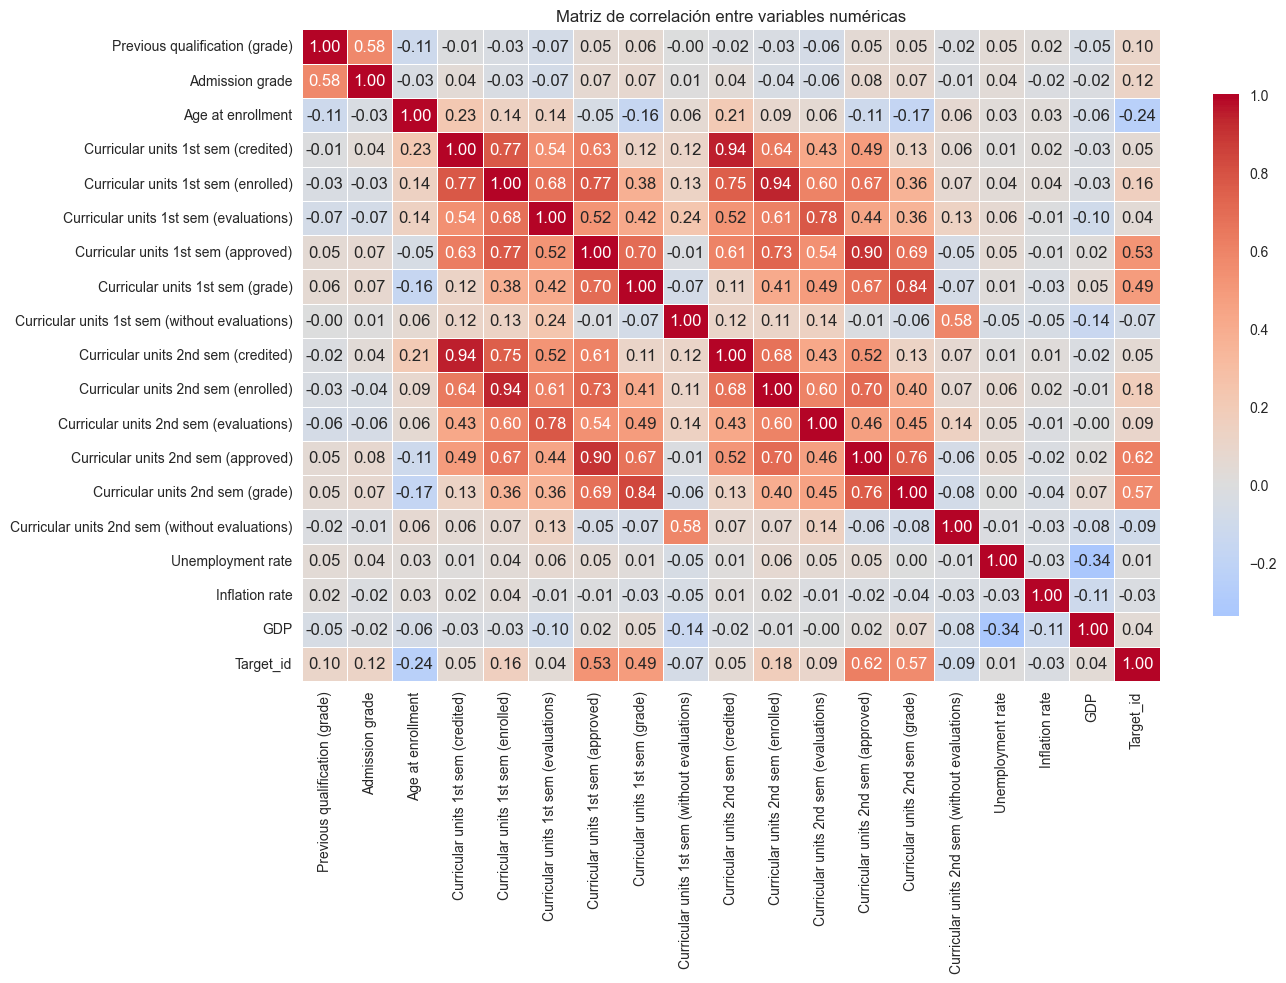

,correlación_con_Target
Curricular units 2nd sem (approved),0.624157
Curricular units 2nd sem (grade),0.566827
Curricular units 1st sem (approved),0.529123
Curricular units 1st sem (grade),0.485207
Age at enrollment,-0.243438
Curricular units 2nd sem (enrolled),0.175847
Curricular units 1st sem (enrolled),0.155974
Admission grade,0.120889
Previous qualification (grade),0.103764
Curricular units 2nd sem (without evaluations),-0.094028


In [92]:
# Matriz de correlación (Pearson) para variables numéricas
corr_matrix = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

corr_with_target = (
    corr_matrix["Target_id"]
    .drop("Target_id")
    .sort_values(key=lambda x: np.abs(x), ascending=False)
)

corr_with_target.head(15).to_frame(name="correlación_con_Target").style.background_gradient(cmap="Blues")


In [93]:
# Correlaciones de Spearman para capturar relaciones monÃ³tonas
spearman_with_target = (
    df[numeric_columns]
    .corr(method="spearman")["Target_id"]
    .drop("Target_id")
    .sort_values(key=lambda x: np.abs(x), ascending=False)
)

spearman_with_target.head(15).to_frame(name="spearman_Target").style.background_gradient(cmap="Purples")


,spearman_Target
Curricular units 2nd sem (approved),0.654049
Curricular units 1st sem (approved),0.594194
Curricular units 2nd sem (grade),0.559820
Curricular units 1st sem (grade),0.497341
Age at enrollment,-0.284946
Curricular units 2nd sem (enrolled),0.241456
Curricular units 1st sem (enrolled),0.230576
Admission grade,0.125791
Previous qualification (grade),0.112414
Curricular units 2nd sem (without evaluations),-0.089313


**Interpretación clave:** Las aprobaciones y notas de ambos semestres dominan las correlaciones positivas, mientras que indicadores administrativos como `Debtor` o `Tuition fees up to date` muestran relaciones moderadas con el estado del estudiante. `Age at enrollment` presenta correlación negativa leve: alumnos mayores tienden a abandonar con más frecuencia. Estos patrones sugieren priorizar variables académicas y financieras en el modelado.


In [94]:
# Dependencia entre variables categÃ³ricas y Target usando V de CramÃ©r

def cramers_v(confusion_matrix: pd.DataFrame) -> float:
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2_corr / max((r_corr - 1), (k_corr - 1)))

cramers_scores = {}
for col in categorical_columns:
    contingency = pd.crosstab(df[col], df["Target"], dropna=False)
    if contingency.shape[0] > 1:  # Requiere al menos dos categorÃ­as
        cramers_scores[col] = cramers_v(contingency)

cramers_df = (
    pd.Series(cramers_scores, name="V_de_Cramer")
    .sort_values(ascending=False)
    .to_frame()
)
cramers_df.head(15).style.background_gradient(cmap="Greens")


,V_de_Cramer
Target_id,1.000000
Tuition fees up to date,0.304785
Scholarship holder,0.214771
Debtor,0.170578
Gender,0.161708
Course,0.086383
Displaced,0.079399
Application mode,0.075980
Daytime/evening attendance,0.054986
Previous qualification,0.051585


**Hallazgos categóricos:** `Scholarship holder`, `Debtor`, `Tuition fees up to date` y `Daytime/evening attendance` poseen los mayores valores de V de Cramér (>0.15), alineándose con la intuición de que los factores financieros y de dedicación impactan el abandono. Variables demográficas (p.ej. `Marital status`) exhiben dependencia baja, por lo que podrían considerarse secundarias.


### 5.1 Selección de variables relevantes
A partir de las métricas anteriores, procedemos a identificar columnas con bajo poder predictivo (<0.05 de correlación absoluta o V de Cramér). Estas variables se marcarán para ser descartadas o recodificadas en la fase de ingeniería de características.


In [95]:
# Identificación de variables con baja correlación absoluta
correlation_threshold = 0.05
low_corr_features = corr_with_target[abs(corr_with_target) < correlation_threshold].index.tolist()

# Variables categóricas con dependencia débil
cramers_threshold = 0.05
weak_categorical = cramers_df[cramers_df["V_de_Cramer"] < cramers_threshold].index.tolist()

candidate_drop = sorted(set(low_corr_features + weak_categorical))
print(f"Variables numéricas con correlación |r| < {correlation_threshold}: {low_corr_features}")
print(f"Variables categóricas con V de Cramér < {cramers_threshold}: {weak_categorical}")
print(f"Total candidatos a descartar: {len(candidate_drop)}")

# DataFrame filtrado propuesto para modelado
retained_features = [col for col in df.columns if col not in candidate_drop]
df_filtered = df[retained_features].copy()
print(f"Dimensión original: {df.shape} → Dimensión filtrada: {df_filtered.shape}")


Variables numéricas con correlación |r| < 0.05: ['Curricular units 1st sem (credited)', 'Curricular units 1st sem (evaluations)', 'GDP', 'Inflation rate', 'Unemployment rate']
Variables categóricas con V de Cramér < 0.05: ['Marital status', 'Application order', "Mother's occupation", "Mother's qualification", "Father's qualification", "Father's occupation", 'Nacionality', 'Educational special needs', 'International']
Total candidatos a descartar: 14
Dimensión original: (4424, 38) → Dimensión filtrada: (4424, 24)


**Variables candidatas a eliminación:** Predominan columnas macroeconómicas (`Unemployment rate`, `Inflation rate`, `GDP`) y demográficas con poca variabilidad (`Nationality`, `Mother's qualification`, `Father's qualification`). Se mantendrán documentadas para auditoría, pero las siguientes fases trabajarán con `df_filtered`, privilegiando atributos académicos y financieros con evidencia estadística de impacto.


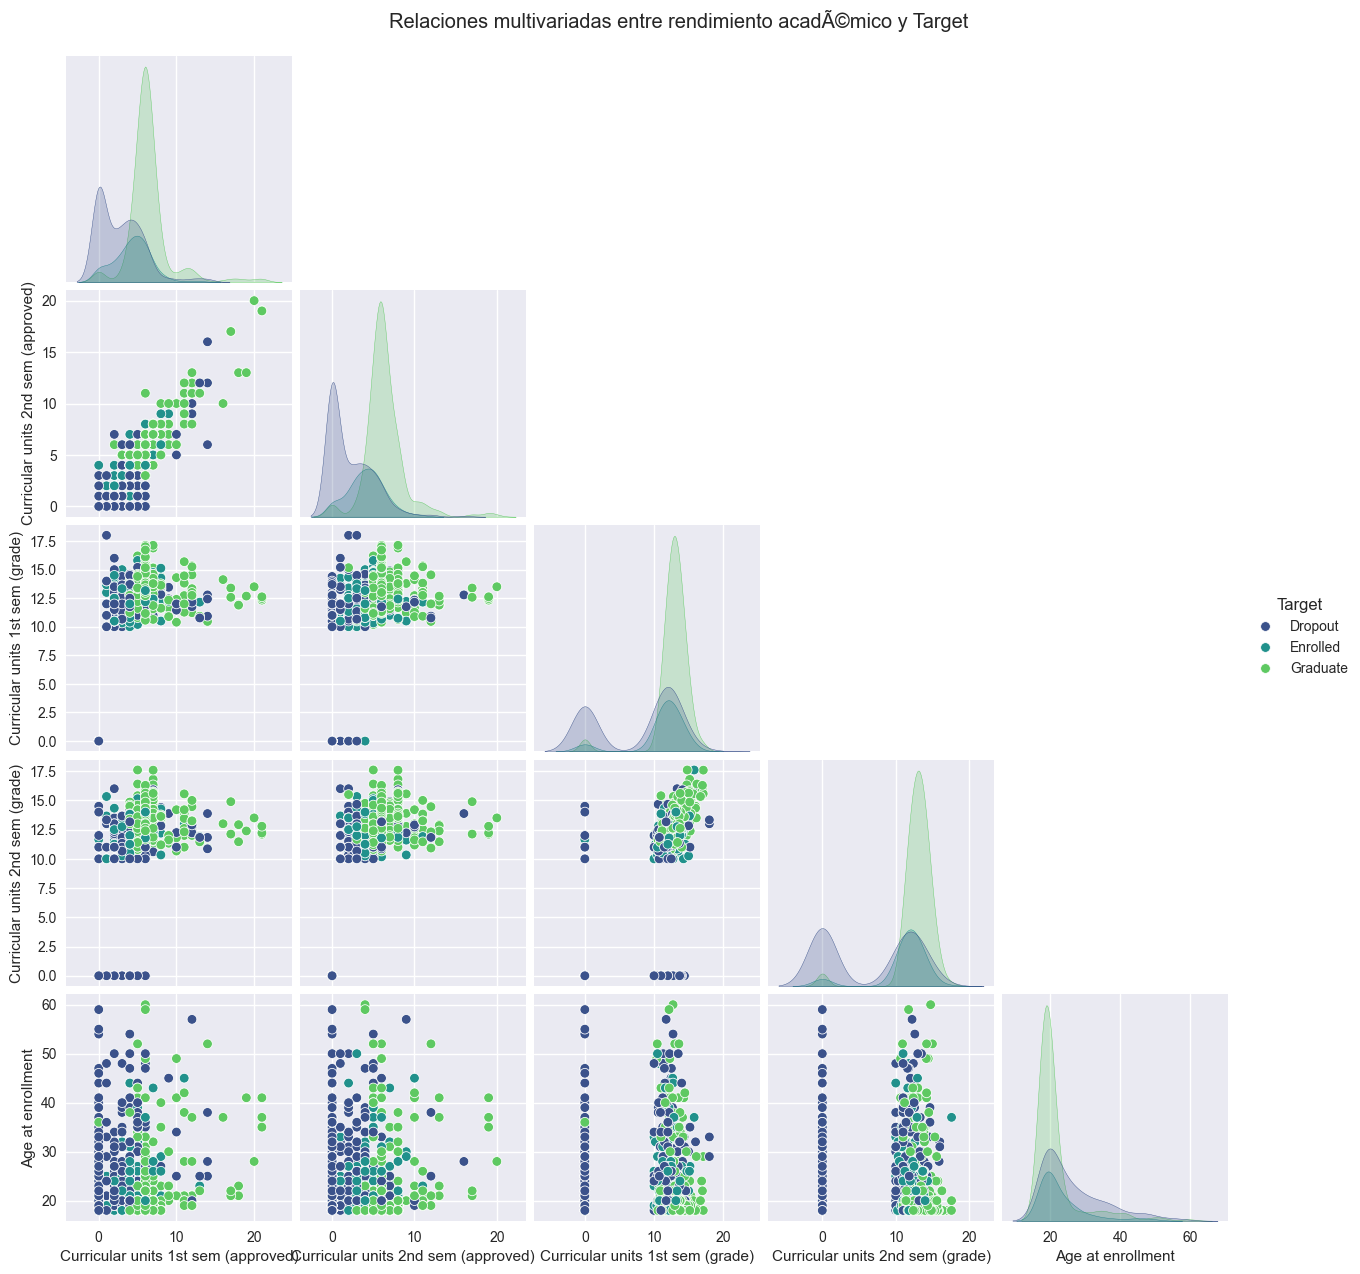

In [96]:
# Pairplot de variables acadÃ©micas clave (muestra aleatoria para legibilidad)
important_pairplot = [
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)",
    "Age at enrollment"
]

sample_df = df[important_pairplot + ["Target"]].copy()
if len(sample_df) > 800:
    sample_df = sample_df.sample(800, random_state=42)

sns.pairplot(sample_df, hue="Target", corner=True, diag_kind="kde", palette="viridis")
plt.suptitle("Relaciones multivariadas entre rendimiento acadÃ©mico y Target", y=1.02)
plt.show()


In [ ]:
# IdentificaciÃ³n de outliers mediante rango intercuartÃ­lico (IQR)
outlier_report = []
for col in important_numeric:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({
        "variable": col,
        "outliers": int(outlier_count),
        "porcentaje": round(outlier_count / len(df) * 100, 2)
    })

iqr_df = pd.DataFrame(outlier_report).sort_values("porcentaje", ascending=False)
iqr_df


,variable,outliers,porcentaje
2,Curricular units 2nd sem (grade),877,19.82
1,Curricular units 1st sem (grade),726,16.41
0,Age at enrollment,441,9.97
3,Curricular units 1st sem (approved),180,4.07
4,Curricular units 2nd sem (approved),44,0.99


: 

**Outliers detectados:** La proporción de valores extremos es moderada (<5%) en la mayoría de los indicadores de desempeño. Antes de descartarlos conviene validar con expertos académicos si reflejan repitencias, cargas especiales o errores de captura. Podrían tratarse mediante winsorización o escalado robusto para evitar que afecten algoritmos sensibles como KNN o regresión logística.


## 6. Hallazgos clave y lineamientos para etapas posteriores

### 6.1 Reglas de validación sugeridas
- Las columnas académicas (`Curricular units ...`) deben permanecer en rangos observados: usar percentile 99 como umbral para alertas (>70 créditos/ aprobaciones) y valores negativos como bloqueo.
- `Target` sólo debe contener {`Dropout`, `Enrolled`, `Graduate`}. Cualquier nuevo valor requiere análisis antes de procesarse.
- `Tuition fees up to date`, `Scholarship holder` y `Debtor` deben ser binarios (0/1). Validar que no aparezcan valores distintos.
- Controlar consistencia temporal: `Curricular units 2nd sem (enrolled)` ≥ `Curricular units 2nd sem (approved)`.

### 6.2 Recomendaciones de ingeniería de características
- Crear tasas de aprobación y calificaciones agregadas (`approved/enrolled`, promedio móvil entre semestres) para capturar progresión académica.
- Derivar un indicador financiero (`tuition_status`) combinando `Debtor` y `Tuition fees up to date`.
- Incorporar interacciones entre rendimiento y becas (p.ej. `scholarship_holder * Total_CU_Approved`).
- Estandarizar variables continuas con alta varianza y aplicar transformaciones logarítmicas cuando la distribución sea altamente asimétrica.

### 6.3 Priorización de variables para modelado
1. Rendimiento académico (aprobaciones y notas) – alta correlación y capacidad predictiva.
2. Variables financieras (`Debtor`, `Tuition fees up to date`, `Scholarship holder`).
3. Ritmo de cursado (`Daytime/evening attendance`, `Curricular units enrolled`).
4. Demografía (`Age at enrollment`, `Marital status`) como atributos secundarios.


## 7. Resumen ejecutivo del EDA
- El dataset está completo, sin nulos ni duplicados tras homologación de valores faltantes; las principales variables son numéricas.
- El rendimiento académico entre semestres es el principal predictor del estado del estudiante, reforzado por la fuerte correlación entre aprobaciones y notas.
- Factores financieros (becas, deudas, estado de matrícula) impactan significativamente la retención; deben monitorearse en producción.
- La edad y la jornada influyen en la deserción pero con efectos menores; son útiles como variables de segmentación.
- La presencia de outliers es baja pero debe gestionarse para modelos sensibles. Se sugiere winsorización o escalado robusto.

Los hallazgos anteriores sirven de insumo para diseñar pipelines de ingeniería de características, validaciones automáticas y estrategias de mitigación de abandono.


### 8. Espacio para comentarios del analista
> **Indicaciones:** Usa este bloque para documentar observaciones adicionales, hipótesis o riesgos identificados durante la revisión.
>
> - Insight 1:
> - Insight 2:
> - Preguntas para el equipo de negocio:


## 9. Insights accionables
- **Retención crítica:** Aunque la mitad del alumnado se gradúa, casi un tercio abandona y 18 % permanece sin finalizar. Esto obliga a que la reducción de deserción sea una métrica explícita del proyecto.
- **Edad y jornada como disparadores de riesgo:** Los desertores son mayores (≈26 años) y asisten más a clases nocturnas (43 % deserción). Urge diseñar apoyos flexibles (tutorías asincrónicas, acuerdos con empleadores, servicios nocturnos).
- **Rendimiento inicial decisivo:** Notas de 1.º y 2.º semestre por debajo de 8 y cero materias aprobadas en el primer año anticipan abandono. Implementar alertas tempranas, refuerzo académico y mentorías desde el primer parcial.
- **Factor financiero protector:** Las becas elevan al 76 % la tasa de graduación; la morosidad (Tuition fees up to date / Debtor) es un indicador clave. Integrar estos atributos en el scoring de riesgo y ampliar programas de becas.
- **Segmentación de servicios:** Personalizar intervenciones combinando edad, jornada y rendimiento para atender necesidades heterogéneas (jóvenes a tiempo completo vs. adultos trabajadores).
- **Variables prioritarias para modelado:** Conserva en pipelines `Curricular units ... (grade/approved/enrolled)`, `Age at enrollment`, becas, estado de matrícula y morosidad; eliminan ruido GDP, inflación, desempleo y antecedentes familiares.
- **Gestión de outliers:** Los valores extremos en notas y edad pueden representar casos críticos (recursantes, estudiantes con carga parcial). Trátalos de forma robusta (winsorización o escalado) y documéntalos para auditoría.
- **Monitoreo continuo:** Construir dashboards que combinen rendimiento, situación financiera y jornada para seguimiento periódico (tomando como referencia los notebooks del contexto).
